In [1]:
import numpy as np
import gymnasium as gym
from typing import Dict, Tuple, Optional
from enum import Enum
from gymnasium.error import DependencyNotInstalled
from envs.stowage_gym import StowageEnv
config_dict = {
    "vessel_shape": (3,5,3),
    "yard_shape": (3,5,3),
    "num_containers": 50,
    "group_num": 3,
    "group_placement": "random",
    "seed": 4307,
}
env = StowageEnv(config=config_dict, render_mode="rgb_array")
observation, info = env.reset()

In [2]:
obs, info = env.reset()
print(obs)

[1 1 1 0 0 1 1 2 0 0 1 1 3 0 0 1 2 1 0 0 1 2 2 0 0 1 2 3 0 0 1 3 1 0 0 1 3
 2 0 0 1 3 3 0 0 1 4 1 0 0 1 4 2 0 0 1 4 3 0 0 1 5 1 0 0 1 5 2 0 0 1 5 3 0
 0 2 1 1 0 0 2 1 2 0 0 2 1 3 0 0 2 2 1 0 0 2 2 2 0 0 2 2 3 0 0 2 3 1 0 0 2
 3 2 0 0 2 3 3 0 0 2 4 1 0 0 2 4 2 0 0 2 4 3 0 0 2 5 1 0 0 2 5 2 0 0 2 5 3
 0 0 3 1 1 0 1 3 1 2 0 1 3 1 3 0 1 3 2 1 0 1 3 2 2 0 1 3 2 3 0 1 3 3 1 0 1
 3 3 2 0 1 3 3 3 0 1 3 4 1 0 1 3 4 2 0 1 3 4 3 0 1 3 5 1 0 1 3 5 2 0 1 3 5
 3 0 1 5 1 1 0 2 5 1 2 0 2 5 1 3 0 2 5 2 1 0 2 5 2 2 0 2 5 2 3 0 2 5 3 1 0
 2 5 3 2 0 2 5 3 3 0 2 5 4 1 0 2 5 4 2 0 2 5 4 3 0 2 5 5 1 0 2 5 5 2 0 2 5
 5 3 0 2 1 1 1 1 1 1 1 2 1 1 1 1 3 1 1 1 2 1 1 2 1 2 2 1 0 1 2 3 1 0 1 3 1
 1 0 1 3 2 1 1 1 3 3 1 0 1 4 1 1 2 1 4 2 1 2 1 4 3 1 2 1 5 1 1 2 1 5 2 1 0
 1 5 3 1 1 2 1 1 0 0 2 1 2 0 0 2 1 3 0 0 2 2 1 0 0 2 2 2 0 0 2 2 3 0 0 2 3
 1 0 0 2 3 2 0 0 2 3 3 0 0 2 4 1 0 0 2 4 2 0 0 2 4 3 0 0 2 5 1 0 0 2 5 2 0
 0 2 5 3 0 0 3 1 1 1 1 3 1 2 1 0 3 1 3 1 2 3 2 1 1 0 3 2 2 1 0 3 2 3 1 0 3
 3 1 1 0 3 3 2 1 0 3 3 3 

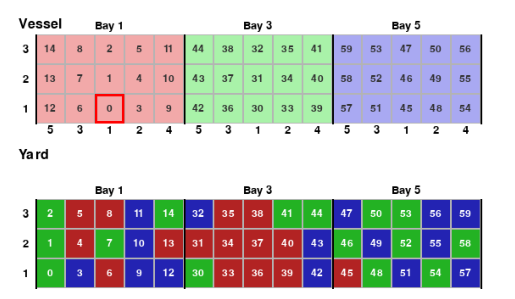

In [3]:
import matplotlib.pyplot as plt

# Get the RGB array
rgb_array = env.render()

# Display the image
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()

Reward: -2
Info: {'yard_mask': array([ 4,  7, 13, 31, 33, 34, 35, 36, 37, 39]), 'shifters': 2, 'vessel_slots_filled': 5}
Terminated: False


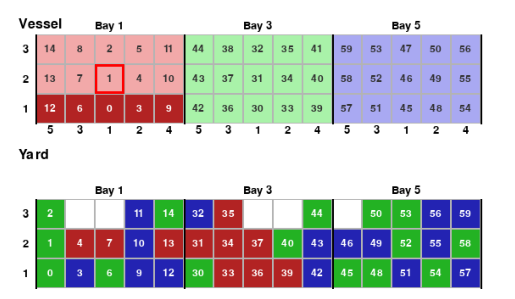

In [9]:
observation, reward, terminated, truncated, info = env.step(36)
print('Reward:', reward)
print('Info:', info)
print('Terminated:', terminated)
rgb_array = env.render()
plt.imshow(rgb_array)
plt.axis('off')
plt.show()

In [ ]:
import copy
import numpy as np

def enumeration_solver(env):
    best_reward = -float('inf')
    best_actions = []

    def dfs(current_env, current_actions, current_reward):
        nonlocal best_reward, best_actions
        valid_actions = current_env._get_valid_yard_actions().tolist()
        
        if not valid_actions:
            if current_reward > best_reward:
                best_reward = current_reward
                best_actions = current_actions.copy()
            return

        for action in valid_actions:
            new_env = copy.deepcopy(current_env)
            _, reward, terminated, _, _ = new_env.step(action)
            new_total_reward = current_reward + reward

            if terminated:
                if new_total_reward > best_reward:
                    best_reward = new_total_reward
                    best_actions = current_actions + [action]
            else:
                dfs(new_env, current_actions + [action], new_total_reward)

    initial_env = copy.deepcopy(env)
    initial_env.reset()
    dfs(initial_env, [], 0)

    return best_actions, best_reward

In [ ]:
env = StowageEnv(config=config_dict)
best_actions, best_reward = enumeration_solver(env)
print('Best reward:', best_reward)


In [ ]:
import numpy as np
import pickle
import time
from copy import deepcopy
import matplotlib.pyplot as plt

class QLearningAgent:
    def __init__(self, learning_rate=0.1, gamma=0.99, exploration_rate=1.0,
                 exploration_decay=0.995, min_exploration_rate=0.01):

        self.q_table = {} 
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay
        self.min_exploration_rate = min_exploration_rate
        
    def state_to_key(self, observation):
        vessel_part = observation[:-self.yard_size-1]
        yard_part = observation[-self.yard_size-1:-1]
        current_target = observation[-1]
        
        vessel_occupied = tuple(vessel_part[:, 3].astype(int))
        yard_occupied = tuple(yard_part[:, 3].astype(int))
        yard_groups = tuple(yard_part[:, 4].astype(int))
        
        target_slot = tuple(current_target[:3])
        target_group = int(current_target[4])
        
        return (vessel_occupied, yard_occupied, yard_groups, target_slot, target_group)
    
    def get_q_value(self, state_key, action):
        """Get Q-value for a state-action pair, defaulting to 0 if not seen before"""
        return self.q_table.get((state_key, action), 0.0)
        
    def choose_action(self, env, observation):
        valid_actions = env._get_valid_yard_actions().tolist()
        
        if not valid_actions:
            return None 

        state_key = self.state_to_key(observation)

        if np.random.random() < self.exploration_rate:
            return np.random.choice(valid_actions)

        q_values = [self.get_q_value(state_key, action) for action in valid_actions]
        max_q_idx = np.argmax(q_values)
        
        return valid_actions[max_q_idx]
    
    def update(self, state_key, action, reward, next_state_key, next_valid_actions):
        current_q = self.get_q_value(state_key, action)
        
        # Max Q-value for next state
        max_next_q = 0.0
        if next_valid_actions:  # If there are valid actions in the next state
            next_q_values = [self.get_q_value(next_state_key, next_action) 
                            for next_action in next_valid_actions]
            max_next_q = max(next_q_values)
        
        # Q-learning update
        new_q = current_q + self.learning_rate * (
            reward + self.gamma * max_next_q - current_q)
        
        # Update Q-table
        self.q_table[(state_key, action)] = new_q
        
    def decay_exploration(self):
        self.exploration_rate = max(
            self.min_exploration_rate,
            self.exploration_rate * self.exploration_decay)
            
    def save(self, filename):
        """Save Q-table to file"""
        with open(filename, 'wb') as f:
            pickle.dump(self.q_table, f)
            
    def load(self, filename):
        """Load Q-table from file"""
        with open(filename, 'rb') as f:
            self.q_table = pickle.load(f)


def train_agent(env, agent, num_episodes=1000, max_steps=100, evaluate_every=100):
    # Set the yard size for state representation
    agent.yard_size = env.total_yard_coords
    
    # Training statistics
    episode_rewards = []
    evaluation_rewards = []
    
    start_time = time.time()
    
    for episode in range(num_episodes):
        # Reset environment
        observation, _ = env.reset()
        total_reward = 0
        
        for step in range(max_steps):
            # Choose action
            action = agent.choose_action(env, observation)
            
            if action is None:
                break  # No valid actions
                
            # Take action
            state_key = agent.state_to_key(observation)
            next_observation, reward, terminated, truncated, info = env.step(action)

            next_valid_actions = [] if terminated else env._get_valid_yard_actions().tolist()
            next_state_key = agent.state_to_key(next_observation)

            agent.update(state_key, action, reward, next_state_key, next_valid_actions)
            
            total_reward += reward
            observation = next_observation
            
            if terminated or truncated:
                break
                
        episode_rewards.append(total_reward)

        agent.decay_exploration()
        
        if (episode + 1) % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            print(f"Episode {episode+1}/{num_episodes}, "
                  f"Avg Reward: {avg_reward:.2f}, "
                  f"Exploration: {agent.exploration_rate:.4f}")

        if (episode + 1) % evaluate_every == 0:
            eval_reward = evaluate_agent(env, agent)
            evaluation_rewards.append(eval_reward)
            print(f"Evaluation at episode {episode+1}: {eval_reward:.2f}")
            
    total_time = time.time() - start_time
    print(f"Training completed in {total_time:.2f} seconds")
    
    # Plot training progress
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(episode_rewards)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    
    plt.subplot(1, 2, 2)
    plt.plot(range(evaluate_every, num_episodes+1, evaluate_every), evaluation_rewards)
    plt.title('Evaluation Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    
    plt.tight_layout()
    plt.show()
    
    return agent


def evaluate_agent(env, agent, num_episodes=5, render=False):
    """
    Evaluate agent performance
    
    Args:
        env: StowageEnv environment
        agent: QLearningAgent
        num_episodes: Number of episodes to evaluate
        render: Whether to render the environment
    
    Returns:
        mean_reward: Average reward across episodes
    """
    rewards = []
    
    for episode in range(num_episodes):
        observation, _ = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            # Get valid actions
            valid_actions = env._get_valid_yard_actions().tolist()
            
            if not valid_actions:
                break
                
            # Convert observation to state key
            state_key = agent.state_to_key(observation)
            
            # Select best action (no exploration)
            q_values = [agent.get_q_value(state_key, action) for action in valid_actions]
            action = valid_actions[np.argmax(q_values)]
            
            # Take action
            observation, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
            
            # Render if requested
            if render and env.render_mode == "rgb_array":
                plt.figure(figsize=(10, 6))
                plt.imshow(env.render())
                plt.axis('off')
                plt.title(f"Action: {action}, Reward: {reward}")
                plt.pause(0.5)
                plt.close()
                
        rewards.append(total_reward)
        
    mean_reward = np.mean(rewards)
    return mean_reward


def visualize_solution(env, agent):
    """
    Visualize agent's solution
    
    Args:
        env: StowageEnv environment
        agent: Trained QLearningAgent
    """
    
    observation, _ = env.reset()
    total_reward = 0
    steps = 0
    
    plt.figure(figsize=(12, 8))
    
    # Initial state
    plt.subplot(1, 2, 1)
    plt.imshow(env.render())
    plt.title("Initial State")
    plt.axis('off')
    
    # Execute solution
    while True:
        # Get valid actions
        valid_actions = env._get_valid_yard_actions().tolist()
        
        if not valid_actions:
            break
            
        # Convert observation to state key
        state_key = agent.state_to_key(observation)
        
        # Select best action
        q_values = [agent.get_q_value(state_key, action) for action in valid_actions]
        action = valid_actions[np.argmax(q_values)]
        
        # Take action
        observation, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
    
    # Final state
    plt.subplot(1, 2, 2)
    plt.imshow(env.render())
    plt.title(f"Final State\nTotal Reward: {total_reward:.2f}, Steps: {steps}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
def visualize_solution(env, agent, delay=0.8):
    """
    Visualize agent's solution showing each step
    
    Args:
        env: StowageEnv environment
        agent: Trained QLearningAgent
        delay: Time delay between steps (seconds)
    """
    import time
    from IPython.display import clear_output
    
    observation, _ = env.reset()
    total_reward = 0
    steps = 0
    
    # Show initial state
    rgb_array = env.render()
    plt.figure(figsize=(10, 8))
    plt.imshow(rgb_array)
    plt.title(f"Initial State - Step 0")
    plt.axis('off')
    plt.show()
    time.sleep(delay)
    
    # Execute solution step by step
    while True:
        # Get valid actions
        valid_actions = env._get_valid_yard_actions().tolist()
        
        if not valid_actions:
            print("No valid actions available. Ending visualization.")
            break
            
        # Convert observation to state key
        state_key = agent.state_to_key(observation)
        
        # Select best action
        q_values = [agent.get_q_value(state_key, action) for action in valid_actions]
        action = valid_actions[np.argmax(q_values)]
        
        # Take action
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        
        # Clear previous output for cleaner display
        clear_output(wait=True)
        
        # Render current state
        rgb_array = env.render()
        plt.figure(figsize=(10, 8))
        plt.imshow(rgb_array)
        
        # Add informative title
        action_info = f"Action: {action}"
        reward_info = f"Step Reward: {reward:.2f}"
        total_info = f"Total Reward: {total_reward:.2f}"
        
        # Add any additional info from the environment
        shifters = info.get('shifters', 0)
        vessel_filled = info.get('vessel_slots_filled', 0)
        
        plt.title(f"Step {steps}: {action_info}, {reward_info}, Shifters: {shifters}\n{total_info}")
        plt.axis('off')
        plt.show()
        
        # Pause to allow viewing
        time.sleep(delay)
        
        if terminated or truncated:
            print(f"Solution completed in {steps} steps with total reward: {total_reward:.2f}")
            break
    
    # Final summary
    print(f"Final Statistics:")
    print(f"- Total Steps: {steps}")
    print(f"- Total Reward: {total_reward:.2f}")

In [ ]:
# Import required modules
import numpy as np
from envs.stowage_gym import StowageEnv

# Create environment
config_dict = {
    "vessel_shape": (2, 2, 2),
    "yard_shape": (2, 2, 2),
    "num_containers": 10,
    "group_num": 4,
    "group_placement": "random",
    "seed": 4307,
}
env = StowageEnv(config=config_dict, render_mode="rgb_array")

# Create and train Q-learning agent
agent = QLearningAgent(
    learning_rate=0.1,
    gamma=0.99,
    exploration_rate=1.0,
    exploration_decay=0.99,
    min_exploration_rate=0.01
)

# Train agent
trained_agent = train_agent(
    env=env,
    agent=agent,
    num_episodes=100,
    max_steps=70,
    evaluate_every=50
)

